# GNN Routing - Graph Convolutional Network for Traffic-Aware Routing
### PyTorch Geometric: https://pytorch-geometric.readthedocs.io
### Data prepared by: data_prep.ipynb

**Overview:**
Trains a Graph Convolutional Network (GCN) on the road graph and congestion time series produced by `data_prep.ipynb`. The GCN learns to predict a congestion score for each road segment (edge) given the current traffic state at neighboring zones (nodes). These predicted scores are used as edge weights in Dijkstra's algorithm to recommend the least-congested route between any two zones.

**Why GCN:**
A GCN propagates information across the graph — the predicted congestion on one road segment is informed by traffic conditions on neighboring segments. This captures the spatial dependency structure of traffic described in the literature: congestion at one node influences adjacent nodes.

**Baseline comparison:**
GNN-predicted routing is compared against uniform-weight Dijkstra (treats all roads as equally congested) to demonstrate the value of learned congestion prediction.

---
## Cell 1 - Environment Setup

In [16]:
# import dependencies
import sys
import os
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import subprocess
import numpy as np
import networkx as nx
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from IPython.display import display as ipy_display, Image as IPyImage

# checks that dependencies are available
print(f"Python           : {sys.version}")
print(f"PyTorch          : {torch.__version__}")
print(f"CUDA             : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    subprocess.run(['bash', '-c', 'module load cuda/11.8.0'], shell=False)

import torch_geometric
print(f"PyG              : {torch_geometric.__version__}")

# File paths — change BASE_DIR if your project is in a different location
BASE_DIR    = os.path.expanduser('~/AdvAI_Final')
DATA_PATH   = os.path.join(BASE_DIR, 'routing', 'data_prep_output.pt')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'routing', 'predictions')
MODELS_DIR  = os.path.join(BASE_DIR, 'detection', 'models')
WEBSITE_DIR = os.path.join(BASE_DIR, 'website', 'results')
GNN_CKPT    = os.path.join(MODELS_DIR, 'gnn_routing.pt')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEBSITE_DIR, exist_ok=True)

# Training hyperparameters
HIDDEN_DIM   = 64
NUM_LAYERS   = 3
EPOCHS       = 500
LR           = 0.001
TRAIN_SPLIT  = 0.8   # fraction of timesteps used for training

print(f"\nBase         : {BASE_DIR}")
print(f"Data path    : {DATA_PATH}")
print(f"GNN checkpoint: {GNN_CKPT}")
print(f"Device       : {device}")
print(f"\nHyperparameters:")
print(f"  Hidden dim : {HIDDEN_DIM}")
print(f"  GCN layers : {NUM_LAYERS}")
print(f"  Epochs     : {EPOCHS}")
print(f"  LR         : {LR}")

Python           : 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
PyTorch          : 2.7.1+cu118
CUDA             : True
GPU              : Tesla V100S-PCIE-32GB
PyG              : 2.7.0

Base         : /users/PGS0295/atrautzs/AdvAI_Final
Data path    : /users/PGS0295/atrautzs/AdvAI_Final/routing/data_prep_output.pt
GNN checkpoint: /users/PGS0295/atrautzs/AdvAI_Final/detection/models/gnn_routing.pt
Device       : cuda

Hyperparameters:
  Hidden dim : 64
  GCN layers : 3
  Epochs     : 500
  LR         : 0.001


---
## Cell 2 - Load Dataset

Loads `data_prep_output.pt` and verifies the interface contract — shapes and dtypes must match what the GCN expects.

In [17]:
if not os.path.exists(DATA_PATH):
    print(f"Dataset not found: {DATA_PATH}")
    print("Run data_prep.ipynb first to generate this file.")
else:
    data_dict = torch.load(DATA_PATH, map_location=device)

    edge_index    = data_dict['edge_index'].to(device)     # [2, num_edges]
    node_coords   = data_dict['node_coords'].to(device)    # [num_nodes, 2]
    congestion    = data_dict['congestion'].to(device)     # [num_nodes, num_timesteps]
    num_nodes     = data_dict['num_nodes']
    num_timesteps = data_dict['num_timesteps']
    sequence_ids  = data_dict['sequence_ids']
    seq_node_map  = data_dict['seq_node_map']

    print("Dataset loaded successfully.")
    print()
    print(f"  edge_index    : {edge_index.shape}  dtype={edge_index.dtype}")
    print(f"  node_coords   : {node_coords.shape}  dtype={node_coords.dtype}")
    print(f"  congestion    : {congestion.shape}  dtype={congestion.dtype}")
    print(f"  num_nodes     : {num_nodes}")
    print(f"  num_timesteps : {num_timesteps}")
    print(f"  sequences     : {sequence_ids}")
    print()
    print(f"  Congestion range : [{congestion.min():.4f}, {congestion.max():.4f}]")
    print(f"  Mean congestion  : {congestion.mean():.4f}")

    # Split timesteps into train and val
    split_t    = int(num_timesteps * TRAIN_SPLIT)
    cong_train = congestion[:, :split_t]   # [num_nodes, split_t]
    cong_val   = congestion[:, split_t:]   # [num_nodes, num_timesteps - split_t]
    print()
    print(f"  Train timesteps  : {cong_train.shape[1]}")
    print(f"  Val timesteps    : {cong_val.shape[1]}")

Dataset loaded successfully.

  edge_index    : torch.Size([2, 4692])  dtype=torch.int64
  node_coords   : torch.Size([945, 2])  dtype=torch.float32
  congestion    : torch.Size([945, 100])  dtype=torch.float32
  num_nodes     : 945
  num_timesteps : 100
  sequences     : ['uav0000013_00000_v', 'uav0000013_01073_v', 'uav0000013_01392_v', 'uav0000020_00406_v', 'uav0000071_03240_v', 'uav0000072_04488_v', 'uav0000072_05448_v', 'uav0000072_06432_v', 'uav0000076_00720_v', 'uav0000079_00480_v', 'uav0000084_00000_v', 'uav0000086_00000_v', 'uav0000099_02109_v', 'uav0000117_02622_v', 'uav0000124_00944_v', 'uav0000126_00001_v', 'uav0000137_00458_v', 'uav0000138_00000_v', 'uav0000140_01590_v', 'uav0000143_02250_v', 'uav0000145_00000_v', 'uav0000150_02310_v', 'uav0000182_00000_v', 'uav0000218_00001_v', 'uav0000222_03150_v', 'uav0000239_03720_v', 'uav0000239_12336_v', 'uav0000243_00001_v', 'uav0000244_01440_v', 'uav0000248_00001_v', 'uav0000263_03289_v', 'uav0000264_02760_v', 'uav0000266_03598_v', 

---
## Cell 3 - Define GCN Model

A three-layer Graph Convolutional Network. Each GCNConv layer aggregates features from neighboring nodes, allowing each zone to incorporate the congestion state of adjacent zones. The output is a single congestion score per node — used as edge weight for routing.

**Input features per node:** congestion time series (num_timesteps values)

**Output per node:** predicted congestion score (scalar)

The model is trained to predict the next timestep's congestion from the current state — a one-step forecasting objective that forces it to learn the spatial propagation patterns of congestion across the graph.

In [18]:
class TrafficGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_layers):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        # Input layer
        self.convs.append(GCNConv(in_dim, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Output layer — scalar congestion score per node
        self.convs.append(GCNConv(hidden_dim, 1))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=0.2, training=self.training)
        x = self.convs[-1](x, edge_index)
        return torch.sigmoid(x).squeeze(-1)  # [num_nodes] in [0, 1]


# Input dim is the number of training timesteps
in_dim = cong_train.shape[1]
model  = TrafficGCN(in_dim, HIDDEN_DIM, NUM_LAYERS).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"TrafficGCN architecture:")
print(f"  Input dim    : {in_dim} (train timesteps)")
print(f"  Hidden dim   : {HIDDEN_DIM}")
print(f"  GCN layers   : {NUM_LAYERS}")
print(f"  Output       : 1 congestion score per node")
print(f"  Total params : {total_params:,}")
print()
print(model)

TrafficGCN architecture:
  Input dim    : 80 (train timesteps)
  Hidden dim   : 64
  GCN layers   : 3
  Output       : 1 congestion score per node
  Total params : 9,665

TrafficGCN(
  (convs): ModuleList(
    (0): GCNConv(80, 64)
    (1): GCNConv(64, 64)
    (2): GCNConv(64, 1)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


---
## Cell 4A - Train GCN - 200 Epochs (Default)

Trains TrafficGCN to predict each node's congestion at the next timestep given its neighborhood's current state. Loss is MSE between predicted and actual congestion. Training and validation loss are tracked per epoch.

Starting TrafficGCN training
  Epochs     : 500
  Optimizer  : Adam (lr=0.001)
  Loss       : MSE
  Nodes      : 945
  Edges      : 4692

  Epoch    1/500   loss: 0.233995   best: 0.233995
  Epoch   20/500   loss: 0.083789   best: 0.083789
  Epoch   40/500   loss: 0.048775   best: 0.048775
  Epoch   60/500   loss: 0.026672   best: 0.026437
  Epoch   80/500   loss: 0.019455   best: 0.019207
  Epoch  100/500   loss: 0.016446   best: 0.016446
  Epoch  120/500   loss: 0.015438   best: 0.015438
  Epoch  140/500   loss: 0.015338   best: 0.015037
  Epoch  160/500   loss: 0.014793   best: 0.014603
  Epoch  180/500   loss: 0.014807   best: 0.014281
  Epoch  200/500   loss: 0.015376   best: 0.013786
  Epoch  220/500   loss: 0.014175   best: 0.013786
  Epoch  240/500   loss: 0.013856   best: 0.013715
  Epoch  260/500   loss: 0.014672   best: 0.013471
  Epoch  280/500   loss: 0.013463   best: 0.013209
  Epoch  300/500   loss: 0.013522   best: 0.013080
  Epoch  320/500   loss: 0.013308   best: 0.01

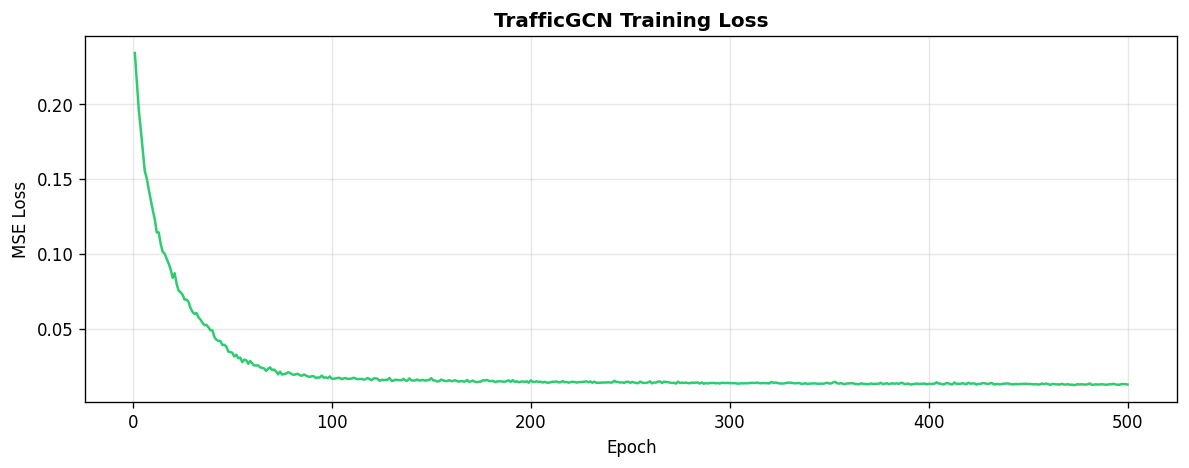

In [19]:
optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
criterion  = nn.MSELoss()

# Build PyG Data object
# x: node features = congestion time series up to split point
# y: target = mean congestion over val period (what we want to predict)
x_train = cong_train                              # [num_nodes, split_t]
y_train = cong_val.mean(dim=1)                   # [num_nodes] — target per node

graph_data = Data(
    x=x_train,
    edge_index=edge_index,
    y=y_train
).to(device)

train_losses = []
best_loss    = float('inf')

print(f"Starting TrafficGCN training")
print(f"  Epochs     : {EPOCHS}")
print(f"  Optimizer  : Adam (lr={LR})")
print(f"  Loss       : MSE")
print(f"  Nodes      : {num_nodes}")
print(f"  Edges      : {edge_index.shape[1]}")
print()

model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    pred = model(graph_data.x, graph_data.edge_index)
    loss = criterion(pred, graph_data.y)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save(model.state_dict(), GNN_CKPT)

    if epoch % 20 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>4}/{EPOCHS}   loss: {loss.item():.6f}   best: {best_loss:.6f}")

print()
print(f"Training complete.")
print(f"Best loss      : {best_loss:.6f}")
print(f"Checkpoint     : {GNN_CKPT}")

# Plot training loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, color='#2ecc71', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('TrafficGCN Training Loss', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
loss_path  = os.path.join(OUTPUT_DIR, 'gnn_training_loss.png')
plt.savefig(loss_path, dpi=120, bbox_inches='tight')
plt.close()
shutil.copy(loss_path, os.path.join(WEBSITE_DIR, 'gnn_training_loss.png'))
ipy_display(IPyImage(filename=loss_path))

---
## Cell 4B - Train GCN - Custom Epochs

In [ ]:
epochs_input  = input("Enter number of epochs for custom run (e.g. 50, 100): ").strip()
EPOCHS_CUSTOM = int(epochs_input)

model_custom  = TrafficGCN(in_dim, HIDDEN_DIM, NUM_LAYERS).to(device)
opt_custom    = torch.optim.Adam(model_custom.parameters(), lr=LR)
losses_custom = []
best_custom   = float('inf')
ckpt_custom   = os.path.join(MODELS_DIR, f'gnn_routing_{EPOCHS_CUSTOM}epoch.pt')

print(f"Starting custom run — {EPOCHS_CUSTOM} epochs")
print()

model_custom.train()
for epoch in range(1, EPOCHS_CUSTOM + 1):
    opt_custom.zero_grad()
    pred = model_custom(graph_data.x, graph_data.edge_index)
    loss = criterion(pred, graph_data.y)
    loss.backward()
    opt_custom.step()
    losses_custom.append(loss.item())
    if loss.item() < best_custom:
        best_custom = loss.item()
        torch.save(model_custom.state_dict(), ckpt_custom)
    if epoch % max(1, EPOCHS_CUSTOM // 5) == 0 or epoch == 1:
        print(f"  Epoch {epoch:>4}/{EPOCHS_CUSTOM}   loss: {loss.item():.6f}")

print()
print(f"Custom training complete. Best loss: {best_custom:.6f}")
print(f"Checkpoint: {ckpt_custom}")

---
## Cell 5 - Evaluate - GNN vs Baseline

Loads the best checkpoint and compares two routing strategies across all node pairs:

- **Baseline** — Dijkstra with uniform edge weights (all roads treated equally)
- **GNN** — Dijkstra with GCN-predicted congestion scores as edge weights

The metric is average route congestion: the mean predicted congestion score along the recommended path. Lower is better — a good router avoids high-congestion edges.

GNN predicted congestion scores per node:
  Node  0: 0.0642
  Node  1: 0.0236
  Node  2: 0.0661
  Node  3: 0.0500
  Node  4: 0.0270
  Node  5: 0.0270
  Node  6: 0.0925
  Node  7: 0.0504
  Node  8: 0.0764
  Node  9: 0.0711
  Node 10: 0.0847
  Node 11: 0.0523
  Node 12: 0.0542
  Node 13: 0.0270
  Node 14: 0.0206
  Node 15: 0.0884
  Node 16: 0.2347
  Node 17: 0.1990
  Node 18: 0.1102
  Node 19: 0.0798
  Node 20: 0.1434
  Node 21: 0.2134
  Node 22: 0.1368
  Node 23: 0.0802
  Node 24: 0.1434
  Node 25: 0.2523
  Node 26: 0.1787
  Node 27: 0.1143
  Node 28: 0.0884
  Node 29: 0.0895
  Node 30: 0.1370
  Node 31: 0.0373
  Node 32: 0.0568
  Node 33: 0.1100
  Node 34: 0.1458
  Node 35: 0.0521
  Node 36: 0.0782
  Node 37: 0.0373
  Node 38: 0.0649
  Node 39: 0.0248
  Node 40: 0.0493
  Node 41: 0.1370
  Node 42: 0.1511
  Node 43: 0.0373
  Node 44: 0.0201
  Node 45: 0.0410
  Node 46: 0.0309
  Node 47: 0.1165
  Node 48: 0.1323
  Node 49: 0.0562
  Node 50: 0.1165
  Node 51: 0.0421
  Node 52: 0.0874
  No

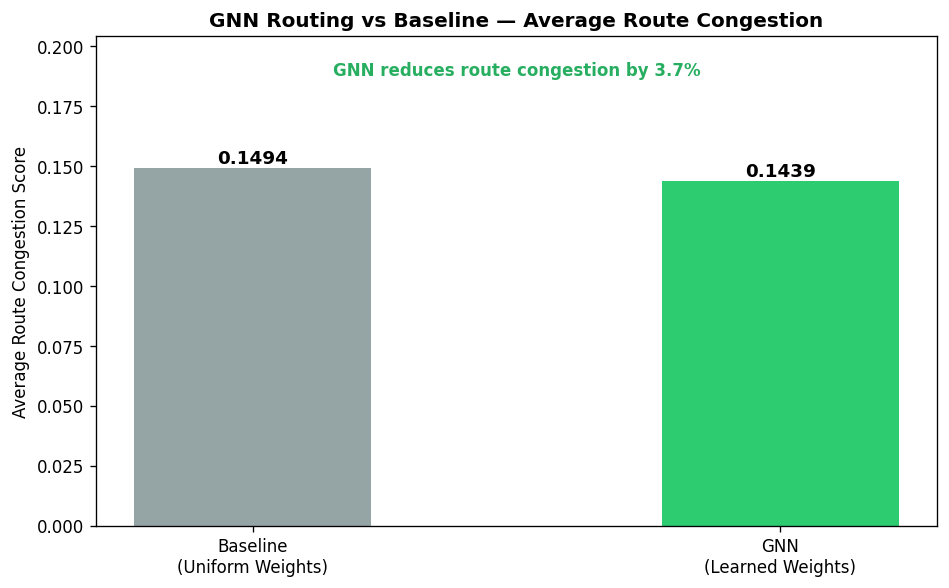

In [20]:
# Load best checkpoint
model.load_state_dict(torch.load(GNN_CKPT, map_location=device))
model.eval()

with torch.no_grad():
    gnn_scores = model(graph_data.x, graph_data.edge_index).cpu().numpy()  # [num_nodes]

print(f"GNN predicted congestion scores per node:")
for i, s in enumerate(gnn_scores):
    print(f"  Node {i:>2}: {s:.4f}")
print()

# Build NetworkX graph for routing
G_baseline = nx.DiGraph()
G_gnn      = nx.DiGraph()

src_list = edge_index[0].cpu().tolist()
dst_list = edge_index[1].cpu().tolist()

for s, d in zip(src_list, dst_list):
    G_baseline.add_edge(s, d, weight=1.0)
    # GNN weight = average predicted congestion of src and dst nodes
    gnn_w = float((gnn_scores[s] + gnn_scores[d]) / 2)
    G_gnn.add_edge(s, d, weight=max(gnn_w, 1e-6))

# Evaluate over all valid source-destination pairs
nodes        = list(range(num_nodes))
baseline_congs = []
gnn_congs      = []
pair_results   = []

for src in nodes:
    for dst in nodes:
        if src == dst:
            continue
        try:
            path_base = nx.shortest_path(G_baseline, src, dst, weight='weight')
            path_gnn  = nx.shortest_path(G_gnn,      src, dst, weight='weight')
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue

        cong_base = float(np.mean([gnn_scores[n] for n in path_base]))
        cong_gnn  = float(np.mean([gnn_scores[n] for n in path_gnn]))
        baseline_congs.append(cong_base)
        gnn_congs.append(cong_gnn)
        pair_results.append((src, dst, path_base, path_gnn, cong_base, cong_gnn))

avg_base = float(np.mean(baseline_congs)) if baseline_congs else 0
avg_gnn  = float(np.mean(gnn_congs))      if gnn_congs      else 0
improv   = ((avg_base - avg_gnn) / avg_base * 100) if avg_base > 0 else 0

# Divergent path metric — only pairs where GNN chose a different route
divergent     = [(b, g) for _, _, pb, pg, b, g in pair_results if pb != pg]
div_base_avg  = float(np.mean([b for b, g in divergent])) if divergent else 0
div_gnn_avg   = float(np.mean([g for b, g in divergent])) if divergent else 0
div_improv    = ((div_base_avg - div_gnn_avg) / div_base_avg * 100) if div_base_avg > 0 else 0

print("=" * 55)
print(f"{'Strategy':<30} {'Avg Route Congestion':>20}")
print("-" * 55)
print(f"{'Baseline (uniform weights)':<30} {avg_base:>20.4f}")
print(f"{'GNN (learned weights)':<30} {avg_gnn:>20.4f}")
print("-" * 55)
print(f"Overall improvement    : {improv:.1f}%")
print(f"Pairs evaluated        : {len(pair_results)}")
print()
print(f"--- Divergent routes only (GNN chose differently) ---")
print(f"Divergent pairs        : {len(divergent)} / {len(pair_results)}")
if divergent:
    print(f"Baseline avg cong      : {div_base_avg:.4f}")
    print(f"GNN avg cong           : {div_gnn_avg:.4f}")
    print(f"Improvement on these   : {div_improv:.1f}%")
print("=" * 55)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Baseline\n(Uniform Weights)', 'GNN\n(Learned Weights)'],
    [avg_base, avg_gnn],
    color=['#95a5a6', '#2ecc71'],
    width=0.45
)
ax.set_ylabel('Average Route Congestion Score')
ax.set_title('GNN Routing vs Baseline — Average Route Congestion',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(avg_base, avg_gnn) * 1.3 + 0.01)
for bar, val in zip(bars, [avg_base, avg_gnn]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.text(0.5, 0.92, f'GNN reduces route congestion by {improv:.1f}%',
        transform=ax.transAxes, ha='center', fontsize=10,
        color='#27ae60', fontweight='bold')
plt.tight_layout()
eval_path = os.path.join(OUTPUT_DIR, 'gnn_vs_baseline.png')
plt.savefig(eval_path, dpi=120, bbox_inches='tight')
plt.close()
shutil.copy(eval_path, os.path.join(WEBSITE_DIR, 'gnn_vs_baseline.png'))
ipy_display(IPyImage(filename=eval_path))

---
## Cell 6 - Interactive - Route Recommendation

Select a sequence, then pick source and destination zones within that scene. The GNN predicts congestion scores and Dijkstra finds the optimal route. Both baseline and GNN paths are displayed overlaid on the actual aerial image from that sequence.

In [10]:
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

# Get GNN scores
model.eval()
with torch.no_grad():
    scores = model(graph_data.x, graph_data.edge_index).cpu().numpy()

coords = node_coords.cpu().numpy()  # [num_nodes, 2]

# Step 1 — show available sequences with edge counts and congestion summary
print("Available sequences (only sequences with edges can be routed):")
print()
print(f"{'Seq ID':<12} {'Zones':>6} {'Edges':>6} {'Avg Cong':>10} {'Max Cong':>10}  Nodes")
print("-" * 65)

routable = {}  # seq_id -> local zone indices (0-based within sequence)
for seq_id, local_nodes in seq_node_map.items():
    # Count edges within this sequence
    s_set  = set(local_nodes)
    n_edges = sum(
        1 for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist())
        if s in s_set and d in s_set
    ) // 2  # bidirectional so divide by 2
    if n_edges == 0:
        continue
    seq_scores = scores[local_nodes]
    routable[seq_id] = local_nodes
    print(f"  {str(seq_id):<10} {len(local_nodes):>6} {n_edges:>6} "
          f"{seq_scores.mean():>10.4f} {seq_scores.max():>10.4f}  "
          f"global {local_nodes[0]}–{local_nodes[-1]}")

print()
print(f"{len(routable)} sequences available for routing.")
print()

# Step 2 — pick a sequence
seq_choice = input("Enter sequence ID from the list above: ").strip()
try:
    seq_choice = int(seq_choice)
except ValueError:
    pass

if seq_choice not in routable:
    print(f"Sequence {seq_choice} not found or has no edges.")
else:
    local_nodes  = routable[seq_choice]
    n_local      = len(local_nodes)
    seq_scores   = scores[local_nodes]  # [n_zones]
    seq_coords   = coords[local_nodes]  # [n_zones, 2]

    # Show local zone summary
    print()
    print(f"Sequence {seq_choice} — {n_local} zones:")
    print(f"  {'Local Zone':>11} {'Global Node':>12} {'Congestion':>12}  Level")
    print("  " + "-" * 46)
    for lz, (gn, sc) in enumerate(zip(local_nodes, seq_scores)):
        level = 'HIGH' if sc > 0.6 else 'MEDIUM' if sc > 0.3 else 'LOW'
        print(f"  {lz:>11} {gn:>12} {sc:>12.4f}  {level}")
    print()

    # Step 3 — pick source and destination local zone
    src_local = int(input(f"Enter source zone (0 to {n_local - 1}): ").strip())
    dst_local = int(input(f"Enter destination zone (0 to {n_local - 1}): ").strip())

    src_global = local_nodes[src_local]
    dst_global = local_nodes[dst_local]

    if src_local == dst_local:
        print("Source and destination must be different.")
    else:
        try:
            path_base_g = nx.shortest_path(G_baseline, src_global, dst_global, weight='weight')
            path_gnn_g  = nx.shortest_path(G_gnn,      src_global, dst_global, weight='weight')
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            print(f"No path found between zone {src_local} and zone {dst_local}.")
            path_base_g, path_gnn_g = None, None

        if path_base_g is not None:
            cong_base = float(np.mean([scores[n] for n in path_base_g]))
            cong_gnn  = float(np.mean([scores[n] for n in path_gnn_g]))

            # Convert global paths back to local zone indices for display
            g_to_l    = {g: l for l, g in enumerate(local_nodes)}
            path_base_l = [g_to_l[n] for n in path_base_g]
            path_gnn_l  = [g_to_l[n] for n in path_gnn_g]

            print(f"\nRoute: Zone {src_local} → Zone {dst_local}")
            print(f"  Baseline path : {' → '.join(map(str, path_base_l))}")
            print(f"  Baseline cong : {cong_base:.4f}")
            print(f"  GNN path      : {' → '.join(map(str, path_gnn_l))}")
            print(f"  GNN cong      : {cong_gnn:.4f}")

            # Find a sample image from this sequence
            sample_img = None
            for split in ['train', 'val', 'test']:
                split_dir = os.path.join(
                    os.path.expanduser('~/AdvAI_Final'),
                    'datasets', 'VisDrone', 'images', split
                )
                if os.path.exists(split_dir):
                    for fname in sorted(os.listdir(split_dir)):
                        if fname.startswith(f'{seq_choice:07d}_') or \
                           fname.startswith(f'{seq_choice}_'):
                            sample_img = os.path.join(split_dir, fname)
                            break
                if sample_img:
                    break

            fig, axes = plt.subplots(1, 2, figsize=(22, 9))
            fig.suptitle(
                f'Route Recommendation — Sequence {seq_choice}: '
                f'Zone {src_local} → Zone {dst_local}',
                fontsize=13, fontweight='bold'
            )

            for ax, path_l, path_g, title, path_color, cong_val in [
                (axes[0], path_base_l, path_base_g,
                 f'Baseline (uniform weights)\nAvg Congestion: {cong_base:.4f}',
                 '#e74c3c', cong_base),
                (axes[1], path_gnn_l,  path_gnn_g,
                 f'GNN (learned weights)\nAvg Congestion: {cong_gnn:.4f}',
                 '#2ecc71', cong_gnn)
            ]:
                # Background — aerial image if available, dark canvas otherwise
                if sample_img:
                    img_arr = mpimg.imread(sample_img)
                    ax.imshow(img_arr, alpha=0.6)
                else:
                    ax.set_facecolor('#2c3e50')

                # Draw all sequence edges in grey
                for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist()):
                    if s in set(local_nodes) and d in set(local_nodes):
                        ax.plot([coords[s][0], coords[d][0]],
                                [coords[s][1], coords[d][1]],
                                color='white', linewidth=1.5, alpha=0.4, zorder=1)

                # Draw recommended path in color
                for i in range(len(path_g) - 1):
                    a, b = path_g[i], path_g[i + 1]
                    ax.plot([coords[a][0], coords[b][0]],
                            [coords[a][1], coords[b][1]],
                            color=path_color, linewidth=5, zorder=2, alpha=0.9)

                # Draw all sequence nodes colored by congestion
                for lz, gn in enumerate(local_nodes):
                    sc = scores[gn]
                    c  = '#e74c3c' if sc > 0.6 else '#f39c12' if sc > 0.3 else '#2ecc71'
                    ax.scatter(coords[gn][0], coords[gn][1],
                               s=350, c=c, zorder=3, edgecolors='white', linewidths=2)
                    ax.text(coords[gn][0] + 6, coords[gn][1] - 6,
                            f'Z{lz}\n{sc:.2f}',
                            color='white', fontsize=8, fontweight='bold',
                            bbox=dict(facecolor='#2c3e50', alpha=0.75,
                                      pad=2, edgecolor='none'), zorder=4)

                # Highlight source and destination
                ax.scatter(seq_coords[src_local][0], seq_coords[src_local][1],
                           s=600, c='#3498db', zorder=5, edgecolors='white', linewidths=2.5)
                ax.scatter(seq_coords[dst_local][0], seq_coords[dst_local][1],
                           s=600, c='#9b59b6', zorder=5, edgecolors='white', linewidths=2.5)

                ax.set_title(title, fontsize=11)
                ax.set_xlabel('X (pixels)')
                ax.set_ylabel('Y (pixels)')

            # Legend
            legend = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
                       markersize=11, label='Source'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6',
                       markersize=11, label='Destination'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71',
                       markersize=11, label='Low congestion (< 0.3)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12',
                       markersize=11, label='Medium congestion (0.3–0.6)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
                       markersize=11, label='High congestion (> 0.6)'),
            ]
            axes[1].legend(handles=legend, loc='lower right', fontsize=9)

            plt.tight_layout()
            out_path  = os.path.join(OUTPUT_DIR,  f'route_seq{seq_choice}_z{src_local}_to_z{dst_local}.png')
            site_path = os.path.join(WEBSITE_DIR, f'route_seq{seq_choice}_z{src_local}_to_z{dst_local}.png')
            plt.savefig(out_path, dpi=120, bbox_inches='tight')
            plt.close()
            shutil.copy(out_path, site_path)
            ipy_display(IPyImage(filename=out_path))
            print(f"\nSaved: {out_path}")

Available sequences (only sequences with edges can be routed):

Seq ID        Zones  Edges   Avg Cong   Max Cong  Nodes
-----------------------------------------------------------------
  uav0000013_00000_v     10     29     0.0495     0.0611  global 0–9
  uav0000013_01073_v     10     28     0.1550     0.1783  global 10–19
  uav0000013_01392_v     10     21     0.0886     0.1449  global 20–29
  uav0000020_00406_v     10     27     0.0544     0.0917  global 30–39
  uav0000071_03240_v     10      9     0.0912     0.2151  global 40–49
  uav0000072_04488_v     10     11     0.1603     0.2530  global 50–59
  uav0000072_05448_v     10      9     0.1907     0.4459  global 60–69
  uav0000072_06432_v     10     13     0.2056     0.3611  global 70–79
  uav0000076_00720_v     10      9     0.1056     0.2946  global 80–89
  uav0000079_00480_v     10     12     0.0154     0.0376  global 90–99
  uav0000084_00000_v     10     30     0.2028     0.2738  global 100–109
  uav0000086_00000_v     10     1

Enter sequence ID from the list above:  uav0000366_00001_v 



Sequence uav0000366_00001_v — 10 zones:
   Local Zone  Global Node   Congestion  Level
  ----------------------------------------------
            0          620       0.2436  LOW
            1          621       0.4415  MEDIUM
            2          622       0.2309  LOW
            3          623       0.1700  LOW
            4          624       0.1300  LOW
            5          625       0.4415  MEDIUM
            6          626       0.1418  LOW
            7          627       0.2388  LOW
            8          628       0.2480  LOW
            9          629       0.1009  LOW



Enter source zone (0 to 9):  0
Enter destination zone (0 to 9):  7



Route: Zone 0 → Zone 7
  Baseline path : 0 → 8 → 1 → 2 → 7
  Baseline cong : 0.2805
  GNN path      : 0 → 8 → 1 → 2 → 7
  GNN cong      : 0.2805


ValueError: Unknown format code 'd' for object of type 'str'